# Comparing Models

*All models are wrong, but some are useful.* -- George Box

So far, you've learned about comparing models to data using maximum likelihood. Assuming that you have a good model for your data, this approach lets you estimate the *parameters* of the model that have generated the data. However, often we don't have a single model that we're sure can generate the data. Maybe we have multiple competing models that we would like to compare and ask: which of these models are (the most) compatible with the data? 

This is where we turn to statistical model comparison. A note ahead: model comparison is really hard! It is very difficult to decisively compare models, especially when you have multiple models that are similar, or when the data are not that informative. Today, we'll be looking at frequentist model comparison tools. Next week, we'll add some Bayesian options to the mix.

## Imports

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set_style("whitegrid")

import numpy as np
import pandas as pd
import scipy.stats

## Likelihood Ratio Tests

You've already learned about maximum likelihood estimation. Let's say you have a spectrum, 

## Loading the Data from the Maximum Likelihood Exercises

This just loads the data from the [Maximum Likelihood Exercise](https://philuttley.github.io/stats-methods-25/06-mle_confint_binning/index.html) and then uses ML to fit them:

In [7]:
def histrebin(mininbin,counts,edges):
    '''Takes as input a minimum counts per bin and a histogram counts and bin edges, and combines 
       adjacent histogram bins as needed so that no bin has less than the required minimum.
       Inputs:
           mininbin - required minimum counts/bin.
           counts, edges - input histogram counts/bin and bin edges arrays.
       Outputs:
           counts2, edges2 - rebinned counts/bin and bin edges arrays'''
    edges2=np.zeros(1)
    counts2=np.zeros(1)
    i=0
    countsum=0
    firstbin_flag = 1
    edges2[0]=edges[0]
    for x in counts:
        countsum=countsum+x
        i=i+1
        if countsum >= mininbin and (sum(counts[i:]) >= mininbin or i == len(counts)):  # The sum over counts in 
            # remaining bins ensures that we are not left with a bin with counts less than our limit at the end.
            if firstbin_flag == 1: # if this is the first bin satisfying our requirement, 
                # do not append but replace bin 0 with countsum
                counts2[0]=countsum
                firstbin_flag = 0 # now we read the first bin we can switch this off
            else:
                counts2=np.append(counts2,countsum)
            edges2=np.append(edges2,edges[i])
            countsum=0        
    return counts2, edges2

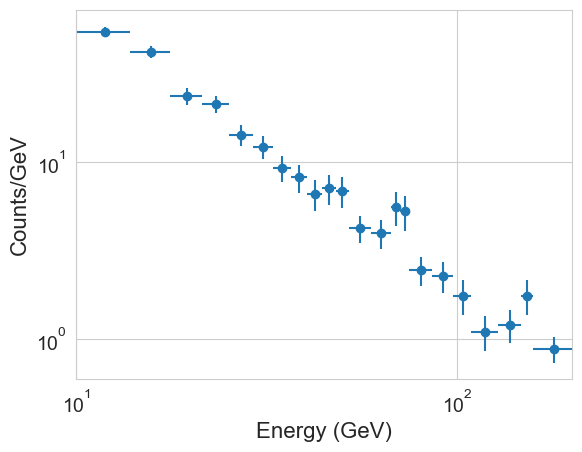

In [10]:
#  First read in the data.  This is a simple (single-column) list of energies:
photens = np.genfromtxt('photon_energies.txt')

# Now we make our unbinned histogram.  We can keep the initial number of bins relatively large.
emin, emax = 10., 200.   # We should always use the known values that the data are sampled over 
                         # for the range used for the bins!
nbins = 50
counts, edges = np.histogram(photens, bins=nbins, range=[emin,emax], density=False)

# And now we use our new function to rebin so there are at least mincounts counts per bin:
mincounts = 20  # Here we set it to our minimum requirement of 20, but in principle you could set it higher
counts2, edges2 = histrebin(mincounts,counts,edges)

bwidths = np.diff(edges2) # calculates the width of each bin
cdens = counts2/bwidths # determines the count densities
cdens_err = np.sqrt(counts2)/bwidths # calculate the errors: remember the error is based on the counts, 
# not the count density, so we have to also apply the same normalisation.
energies = (edges2[:-1]+edges2[1:])/2.  # This calculates the energy bin centres
# Now plot the data - use a log-log scale since we are plotting a power-law
plt.figure()
plt.errorbar(energies, cdens, xerr=bwidths/2., yerr=cdens_err, fmt='o')
plt.xlabel("Energy (GeV)", fontsize=16)
plt.ylabel("Counts/GeV", fontsize=16)
plt.tick_params(labelsize=14)
plt.yscale('log')
plt.xscale('log')
plt.xlim(10.0,200.0)
plt.show()          

In [28]:
import lmfit
from lmfit import Parameters, Minimizer, report_fit
import scipy.stats as sps
import scipy.interpolate as spinterp
import scipy.integrate as spint


In [29]:
def pl_model(x, params):
    '''Simple power-law function.
       Inputs:
           x - input x value(s) (can be list or single value).
           params - lmfit Parameters object: PL normalisation (at x = 1) and power-law index.'''
    v = params.valuesdict()
    return v['N'] * x**v['gamma']

params = Parameters()
params.add_many(('N',2500),('gamma',-1.5))

Let's plot the output: 

In [30]:
def plot_spec_model(ebins,cdens,cdens_err,cdens_model):
    '''Plot the binned (GeV) spectrum with the model as a histogram, and 
       data/model residuals.
       Inputs:
           ebins - energy bin edges.
           cdens, cdens_err - counts density and its error.
           cdens_model - model counts density.'''
    energies = (ebins[1:]+ebins[:-1])/2
    bwidths = np.diff(ebins)
    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(8,6),sharex=True,gridspec_kw={'height_ratios':[2,1]})
    fig.subplots_adjust(hspace=0)
    ax1.errorbar(energies, cdens, xerr=bwidths/2., yerr=cdens_err, fmt='o')
    model_hist, edges, patches = ax1.hist(energies, bins=ebins, weights=cdens_model, 
                                      density=False, histtype='step')
    ax2.errorbar(energies, cdens/cdens_model, xerr=bwidths/2., yerr=cdens_err/cdens_model, fmt='o')
    ax2.set_xlabel("Energy (GeV)", fontsize=16)
    ax1.set_ylabel("Counts/Gev", fontsize=14)
    ax2.set_ylabel("data/model", fontsize=14)
    ax2.axhline(1.0, color='r', linestyle='dotted', lw=2) 
    ax1.tick_params(labelsize=14)
    ax1.tick_params(axis="x",direction="in",which="both", length=4)
    ax2.tick_params(axis="x",which="both", length=4)
    ax2.tick_params(labelsize=14)
    ax1.set_yscale('log')
    ax1.set_xscale('log')
    ax2.set_xscale('log')
    ax1.get_yaxis().set_label_coords(-0.12,0.5)
    ax2.get_yaxis().set_label_coords(-0.12,0.5)
    ax2.set_xlim(ebins[0],ebins[-1]) # Strictly speaking we should only show the energy range 
    # where data is sampled, to avoid impression from model that the flux suddenly drops 
    # at the boundaries.
    plt.show()


In [31]:
def LogLikelihood_Pois(model_counts, counts): 
    '''Calculate the negative Poisson log-likelihood for a model vs counts data. 
       Inputs:
           model_counts - array of predicted model counts per bin
           counts - data: observed counts per bin.
        Outputs: the negative Poisson log-likelihood'''
    pd = sps.poisson(model_counts) #we define our Poisson distribution
    return -1*np.sum(pd.logpmf(counts))

def lmf_poissll(params,xdata,ydata,model,output_ll=True):
    '''lmfit objective function to calculate and return total negative Poisson log-likelihood or model 
        y-values for binned data where the xdata are the contiguous (i.e. no gaps) input bin edges and 
        ydata are the counts (not count densities) per bin.
        Inputs: params - name of lmfit Parameters object set up for the fit.
                xdata, ydata - lists of 1-D arrays of x (must be bin edges not bin centres) 
                and y data and y-errors to be fitted.
                    E.g. for 2 data sets to be fitted simultaneously:
                        xdata = [x1,x2], ydata = [y1,y2], yerrs = [err1,err2], where x1, y1, err1
                        and x2, y2, err2 are the 'data', sets of 1-d arrays of length n1 (n1+1 for x2
                        since it is bin edges), n2 (n2+1 for x2) respectively, 
                        where n1 does not need to equal n2.
                    Note that a single data set should also be given via a list, i.e. xdata = [x1],...
                model - the name of the model function to be used (must take params as its input params and
                        return the model y counts density array for a given x-value array).
                output_resid - Boolean set to True if the lmfit objective function (total -ve 
                        log-likelihood) is required output, otherwise a list of model y-value arrays 
                        (corresponding to the input x-data list) is returned.
        Output: if output_resid==True, returns the total negative log-likelihood. If output_resid==False, 
                returns a list of y-model counts density arrays (one per input x-array)'''
    if output_ll == True:
        poissll = 0
        for i, xvals in enumerate(xdata):  # loop through each input dataset to sum negative log-likelihood
                # We can re-use our model binning function here, but the model then needs to be converted into 
                # counts units from counts density, by multiplying by the bin widths
                ymodel = model_bin(xdata[i],model,params)*np.diff(xdata[i])
                # Then obtain negative Poisson log-likelihood for data (in counts units) vs the model 
                poissll = poissll + LogLikelihood_Pois(ymodel,ydata[i])
        return poissll
    else:
        ymodel = []
        for i, xvals in enumerate(xdata): # record list of model y-value arrays, one per input dataset
            ymodel.append(model_bin(xdata[i],model,params))
        return ymodel

In [40]:
params = Parameters()
params.add_many(('N',2500),('gamma',-1.5))
params.add('gamma',value=-1.5,vary=True)
model = pl_model
output_resid = True
xdata = [edges2]
ydata = [cdens]
yerrs = [cdens_err]
set_function = Minimizer(lmf_lsq_binresid, params, fcn_args=(xdata, ydata, yerrs, model, output_resid),nan_policy='omit')
result = set_function.minimize(method = 'leastsq')
report_fit(result)
print("Minimum Chi-squared = "+str(result.chisqr)+" for "+str(result.nfree)+" d.o.f.")
print("The goodness of fit is: ",sps.chi2.sf(result.chisqr,df=result.nfree))


[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 13
    # data points      = 22
    # variables        = 2
    chi-square         = 20.6520859
    reduced chi-square = 1.03260429
    Akaike info crit   = 2.60902520
    Bayesian info crit = 4.79111011
[[Variables]]
    N:      2695.85938 +/- 372.223329 (13.81%) (init = 2500)
    gamma: -1.57250927 +/- 0.03962484 (2.52%) (init = -1.5)
[[Correlations]] (unreported correlations are < 0.100)
    C(N, gamma) = -0.9734
Minimum Chi-squared = 20.65208589191396 for 20 d.o.f.
The goodness of fit is:  0.4178586593800788


Now we can fit the powerlaw + Gauss model:

In [41]:
def plgauss_model(x, params):
    '''Power-law plus Gaussian function.
       Inputs:
           x - input x value(s) (can be list or single value).
           params - lmfit Parameters object normalisation (at x = 1) and power-law index, 
                Gaussian mean, Gaussian sigma and Gaussian normalisation.'''
    v = params.valuesdict()
    # The line is a Gaussian shape with a normalisation equal to the number of counts in the line
    gflux = np.exp(-0.5*((x - v['gauss_mu'])/v['gauss_sig'])**2)/(v['gauss_sig']*
                                                                  np.sqrt(2.*np.pi))
    return  v['N'] * x**v['gamma'] + v['N_gauss']*gflux

In [42]:
params = Parameters()
params.add_many(('N',2500),('gamma',-1.5),('N_gauss',0),('gauss_mu',70),('gauss_sig',10))


In [43]:
model = plgauss_model
output_resid = True
xdata = [edges2]
ydata = [cdens]
yerrs = [cdens_err]
set_function = Minimizer(lmf_lsq_binresid, params, fcn_args=(xdata, ydata, yerrs, model, output_resid),nan_policy='omit')
result_withgaussian = set_function.minimize(method = 'leastsq')
report_fit(result_withgaussian)
print("Minimum Chi-squared = "+str(result_withgaussian.chisqr)+" for "+
      str(result_withgaussian.nfree)+" d.o.f.")
print("The goodness of fit is: ",sps.chi2.sf(result_withgaussian.chisqr,df=result_withgaussian.nfree))


[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 61
    # data points      = 22
    # variables        = 5
    chi-square         = 14.4301537
    reduced chi-square = 0.84883257
    Akaike info crit   = 0.72210652
    Bayesian info crit = 6.17731879
[[Variables]]
    N:          2795.93479 +/- 363.831715 (13.01%) (init = 2500)
    gamma:     -1.58614475 +/- 0.03763553 (2.37%) (init = -1.5)
    N_gauss:    16.2385196 +/- 183.194634 (1128.15%) (init = 0)
    gauss_mu:   70.8018888 +/- 1.0035e+15 (1417308058481455.00%) (init = 70)
    gauss_sig:  0.45100162 +/- 2.3997e+17 (53207425753759506432.00%) (init = 10)
[[Correlations]] (unreported correlations are < 0.100)
    C(gauss_mu, gauss_sig) = +1.0000
    C(N_gauss, gauss_mu)   = +0.9995
    C(N_gauss, gauss_sig)  = +0.9995
    C(N, gamma)            = -0.9745
    C(N, gauss_sig)        = -0.2091
    C(N, gauss_mu)         = -0.2091
    C(N, N_gauss)          = -0.2056
    C(gamma, gauss_sig)    = +0.2033
    C

Now we can compute the likelihood ratio between the two. Note that the likelihood ratio is defined as the ratio of MLE for $H_1$ to $H_0$. However, the chi-squared value above is the *negative* log-likelihood, so below, we flip the signs to make it all work out correctly. The expression for chi-square also already contains a factor of 2, so we don't need to include it here:

In [51]:
lrt = (result.chisqr - result_withgaussian.chisqr)
print(lrt)

6.22193221630142


### Wilks' Theorem and Chi-Square Distribution

This just plots the chi-square distribution for the emission line problem in the episode so I can put it on the slides:

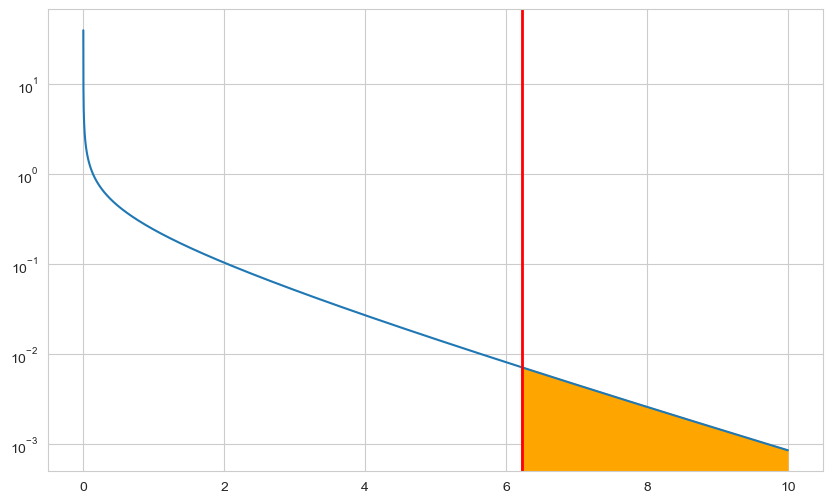

In [54]:
u = np.arange(0, 10, 0.0001)
pdf = scipy.stats.chi2(df=1).pdf(u)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(u, pdf)
ax.axvline(lrt, lw=2, c="red")
ax.fill_between(u[u>=lrt], pdf[u>=lrt], color="orange")
ax.set_yscale("log")

In [55]:
print("p-value for our delta-chi-squared: ",sps.chi2.sf(lrt,df=1))

p-value for our delta-chi-squared:  0.012617733754741173


### Information Criteria.

Let's look at the Akaike and Bayesian Information Criteria. 

The AIC is defined as

$$
\mathrm{AIC} = -2 \log{\hat{\mathcal{L}}} + 2k
$$

for $k$ parameters. 

Eagle-eyed observers will have seen that the LMFit programme actually yields the AIC, so we can use it directly:

In [59]:
print("The difference in AIC is " + str(result_withgaussian.aic - result.aic))

The difference in AIC is -1.886918678341857


The Bayesian Information criterion is defined as

$$
\mathrm{BIC} =  -2 \log{\hat{\mathcal{L}}} + k \log(n)
$$

for $k$ parameters and $n$ data points. This, too, is implemented in LMFIT:

In [60]:
print("The difference in BIC is " + str(result_withgaussian.bic - result.bic))

The difference in BIC is 1.3862086817330912


The AIC and BIC actually disagree here! This is interesting. In general, the BIC is more conservative, than the AIC in claiming the addition of another model component. Here, we have few parameters, but many data points, which will make the BIC much more conservative than the AIC, where the number of data points does not play a role.